In [1]:
import torch
import cv2
import os
import json
import numpy as np
from matplotlib import pyplot as plt

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import pypose as pp
import viser
import time

from better_human.smpl import SMPL
from better_human.smpl.visualize import visualize_single

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
smpl = SMPL("../../better_human/models/smpl/SMPL_NEUTRAL.npz").to(device)

In [3]:
dataset_path = "/data3/rikhat.akizhanov/DECO/"

data_path = os.path.join(dataset_path, "datasets/Release_Datasets/damon", "hot_dca_trainval.npz")
data = np.load(data_path, allow_pickle=True)


for key in data.keys():
    print(key)

imgname
pose
transl
shape
cam_k
polygon_2d_contact
contact_label
scene_seg
part_seg
contact_label_smplx
contact_label_objectwise
contact_label_smplx_objectwise


In [4]:
print("imgname", data["imgname"][0])
print("pose", data["pose"][0].shape)
print("transl", data["transl"][0].shape)
print("shape", data["shape"][0].shape)
print("cam_k", data["cam_k"][0].shape)
print("polygon_2d_contact", data["polygon_2d_contact"][0])
print("contact label", data["contact_label"][0].shape)
print("scene seg", data["scene_seg"][0])
print("contact_label_smplx", data["contact_label_smplx"][0].shape)
print("contact_label_objectwise", data["contact_label_objectwise"][0].keys())
print("contact_label_smplx_objectwise", data["contact_label_smplx_objectwise"][0].keys())

imgname datasets/HOT-Annotated/images/vcoco_000000000589.jpg
pose (72,)
transl (3,)
shape (10,)
cam_k (3, 3)
polygon_2d_contact datasets/HOT-Annotated/polygon_contact/training/vcoco_000000000589.png
contact label (6890,)
scene seg datasets/HOT-Annotated/segmentation_masks/training/vcoco_000000000589.png
contact_label_smplx (10475,)
contact_label_objectwise dict_keys(['frisbee', 'supporting'])
contact_label_smplx_objectwise dict_keys(['frisbee', 'supporting'])


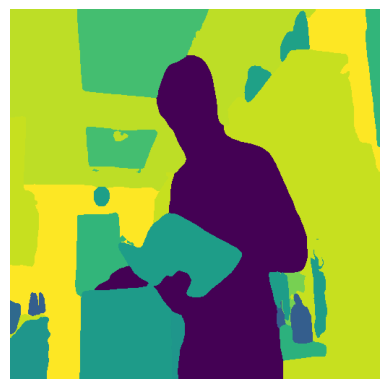

In [5]:
idx = 17

img_path = os.path.join(dataset_path, data["scene_seg"][idx])
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img)
plt.axis('off')
plt.show()

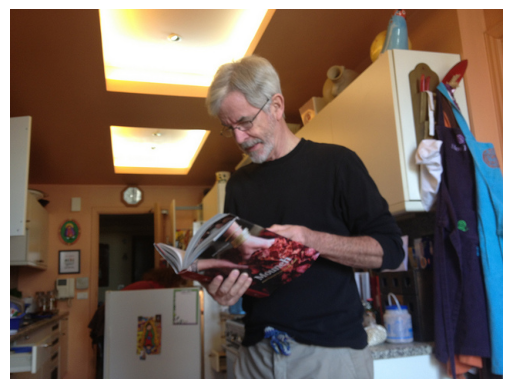

[[800.   0. 320.]
 [  0. 800. 240.]
 [  0.   0.   1.]] (480, 640, 3)


In [6]:
idx = 17

img_path = os.path.join(dataset_path, data["imgname"][idx])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

# polygon_2d_contact = cv2.imread(os.path.join(dataset_path, data["polygon_2d_contact"][idx]))
# polygon_2d_contact = cv2.cvtColor(polygon_2d_contact, cv2.COLOR_BGR2RGB)
# polygon_2d_contact = ((polygon_2d_contact > 1) * 255).astype(np.uint8)

# plt.imshow(polygon_2d_contact)
# plt.axis('off')
# plt.show()

betas = torch.from_numpy(data["shape"][idx]).unsqueeze(0).to(device)
body_pose = torch.from_numpy(data["pose"][idx][3:]).unsqueeze(0).to(device)
# global_orient = torch.from_numpy(data["pose"][idx][:3]).unsqueeze(0)
# transl = torch.from_numpy(data["transl"][idx]).unsqueeze(0)
global_orient = torch.zeros(1, 3).to(device)
transl = torch.zeros(1, 3).to(device)

q = smpl.from_classic(
    betas=betas,
    body_pose=body_pose,
    translation=transl,
    global_orient=global_orient,
)

output = smpl(
    betas=betas,
    q=q,
)

contact_label = data["contact_label"][idx]

print(data["cam_k"][idx], img.shape)

In [7]:
server = viser.ViserServer()

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

In [8]:
visualize_single(
    server=server,
    model=smpl,
    output=output,
    show_joints=False,
    show_mesh=True,
    joint_radius=0.02,
    mesh_color=(10, 127, 255),
    wireframe=False,
)

contact_vertices = output.vertices[0, contact_label.astype(np.bool)].cpu().numpy()

server.scene.add_point_cloud(
    name="/contact_vertices",
    points=contact_vertices,
    colors=(255, 0, 0),
    point_size=0.005,
);

In [9]:
from mhr.mhr import MHR
from conversion import Conversion

In [10]:
# mhr_model = MHR.from_files(lod=1)
mhr_model = torch.jit.load("/data3/rikhat.akizhanov/human_global_motion/data/sam-3d-body-checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt")
mhr_model = mhr_model.to(device)

converter = Conversion(
    mhr_model=mhr_model,
    smpl_model=smpl,
    method="pytorch",   # GPU-enabled
)

In [13]:
# --- Input: classic SMPL params (e.g. from DAMON dataset) ---
B = 1
smpl_params = {
    "betas":         betas,
    "body_pose":     body_pose,   # axis-angle, (J-1)*3
    "global_orient": global_orient,
    "translation":   transl,
}

# Binary contact labels on SMPL mesh [B, 6890]
smpl_contacts = torch.randint(0, 2, (B, 6890)).float()

# --- Convert ---
result = converter.convert_smpl2mhr(
    smpl_parameters=smpl_params,    # drives pose conversion
    contacts=smpl_contacts,         # drives contact interpolation
    return_mhr_parameters=True,
    return_mhr_vertices=True,
    contact_threshold=0.5,
)

mhr_params    = result.result_parameters   # dict with MHR pose/shape params
mhr_vertices  = result.result_vertices     # np.ndarray [B, 18439, 3]
mhr_contacts  = result.result_contacts     # torch.LongTensor [B, 18439]  {0,1}
print(mhr_contacts.shape)  # (8, 18439)

100%|██████████| 1/1 [00:00<00:00, 2616.53it/s]
Head pose, identity, and face expression optimization: 100%|██████████| 1/1 [00:04<00:00,  4.85s/it]
100%|██████████| 1/1 [00:00<00:00, 237.84it/s]

torch.Size([1, 18439])


In [16]:
# visualize mhr vertices
server.scene.add_point_cloud(
    name="/mhr_vertices",
    points=mhr_vertices[0]/100,
    colors=(0, 255, 0),
    point_size=0.005,
)

PointCloudHandle(points=array([[ 1.5140e-05,  3.4985e-01,  2.3035e-01],
       [-3.9101e-03,  3.8940e-01,  2.5586e-01],
       [-6.8903e-04,  3.5645e-01,  2.3657e-01],
       ...,
       [-2.1118e-01, -9.7412e-01, -9.6924e-02],
       [-2.1252e-01, -9.7266e-01, -9.9854e-02],
       [-2.1313e-01, -9.7119e-01, -1.0223e-01]],
      shape=(18439, 3), dtype=float16), colors=array([  0, 255,   0], dtype=uint8), point_size=0.005, point_shape='square', precision='float16')